In [ ]:
#Import the required Libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Cleaning 

### Data Reading & Data Types 

In [2]:
#Read the data in pandas
inp0= pd.read_csv("2. Attribute DataSet.csv")
inp1= pd.read_csv("4. Dress Sales.csv")

You have “Attribute DataSet” which contains a column named “Price”. Choose the correct statement from the following about its data type and variable type.
- Integer type and numerical variable
- Object type and categorical ordinal variable
- Object type and categorical nominal variable
- Float type and categorical variable.


There is another column in “Attribute DataSet” named as “Recommendation”, choose the correct statement about its data type and variable type.
- Integer type and categorical
- Object type and categorical
- Integer type and continuous numerical
- Object type only.


Which of the following column do you think are of no use in “Attribute DataSet”.
- Dress_ID
- Price
- Size and material
- NeckLine
- None of the above


In [3]:
# Print the information about the attributes of inp0 and inp1.
print("Information about inp0 (Attribute DataSet):")
inp0.info()
print("\nFirst few rows of inp0:")
inp0.head()

print("\nInformation about inp1 (Dress Sales):")
inp1.info()
print("\nFirst few rows of inp1:")
inp1.head()

Information about inp0 (Attribute DataSet):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Dress_ID        479 non-null    int64  
 1   Style           479 non-null    object 
 2   Price           477 non-null    object 
 3   Rating          479 non-null    float64
 4   Size            479 non-null    object 
 5   Season          477 non-null    object 
 6   NeckLine        476 non-null    object 
 7   SleeveLength    477 non-null    object 
 8   Material        360 non-null    object 
 9   FabricType      223 non-null    object 
 10  Decoration      255 non-null    object 
 11  Pattern Type    377 non-null    object 
 12  Recommendation  479 non-null    int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 48.8+ KB

First few rows of inp0:

Information about inp1 (Dress Sales):
<class 'pandas.core.frame.DataFrame'>
RangeIndex

,Dress_ID,29-08-2013,31-08-2013,09-02-2013,09-04-2013,09-06-2013,09-08-2013,09-10-2013,09-12-2013,14-09-2013,...,24-09-2013,26-09-2013,28-09-2013,30-09-2013,10-02-2013,10-04-2013,10-06-2013,10-08-2013,10-10-2013,10-12-2013
0,1.006033e+09,2114,2274,2491,2660,2727,2887,2930,3119,3204,...,3554,3624.0,3706,3746.0,3795.0,3832.0,3897,3923.0,3985.0,4048
1,1.212192e+09,151,275,570,750,813,1066,1164,1558,1756,...,2710,2942.0,3258,3354.0,3475.0,3654.0,3911,4024.0,4125.0,4277
2,1.190381e+09,6,7,7,7,8,8,9,10,10,...,11,11.0,11,11.0,11.0,11.0,11,11.0,11.0,11
3,9.660060e+08,1005,1128,1326,1455,1507,1621,1637,1723,1746,...,1878,1892.0,1914,1924.0,1929.0,1941.0,1952,1955.0,1959.0,1963
4,8.763395e+08,996,1175,1304,1396,1432,1559,1570,1638,1655,...,2032,2156.0,2252,2312.0,2387.0,2459.0,2544,2614.0,2693.0,2736


### Fixing the Rows and Columns 

As you can see, there is a column in “Attribute Dataset” named as ‘Size’. This column contains the values in abbreviation format. Write a code in Python to convert the followings:

- M into  “Medium”
- L into  “Large”
- XL into “Extra large”
- free into “Free”
- S, s & small into “Small”.

Now once you are done with changes in the dataset, what is the value of the lowest percentage, the highest percentage and the percentage of Small size categories in the column named “Size”?


In [4]:
# Column fixing, correcting size abbreviation. count the percentage of each size category in "Size" column.
# Display current values in Size column
print("Size column values before transformation:")
print(inp0['Size'].value_counts())

# Create a mapping dictionary for size standardization
size_mapping = {
    'M': 'Medium',
    'L': 'Large',
    'XL': 'Extra large',
    'free': 'Free',
    'S': 'Small',
    's': 'Small',
    'small': 'Small'
}

# Apply the mapping to standardize size values
inp0['Size'] = inp0['Size'].map(lambda x: size_mapping.get(x, x))

# Calculate percentage of each size category
size_counts = inp0['Size'].value_counts(normalize=True) * 100
print("\nPercentage of each size category after transformation:")
print(size_counts)

# Get lowest and highest percentages
lowest_percentage = size_counts.min()
highest_percentage = size_counts.max()
small_percentage = size_counts.get('Small', 0)

print(f"\nLowest percentage: {lowest_percentage:.2f}%")
print(f"Highest percentage: {highest_percentage:.2f}%")
print(f"Small size percentage: {small_percentage:.2f}%")


Size column values before transformation:
Size
M        171
free     165
L         93
S         34
XL        14
small      1
s          1
Name: count, dtype: int64

Percentage of each size category after transformation:
Size
Medium         35.699374
Free           34.446764
Large          19.415449
Small           7.515658
Extra large     2.922756
Name: proportion, dtype: float64

Lowest percentage: 2.92%
Highest percentage: 35.70%
Small size percentage: 7.52%


Count of each size category:
Size
Medium         171
Free           165
Large           93
Small           36
Extra large     14
Name: count, dtype: int64


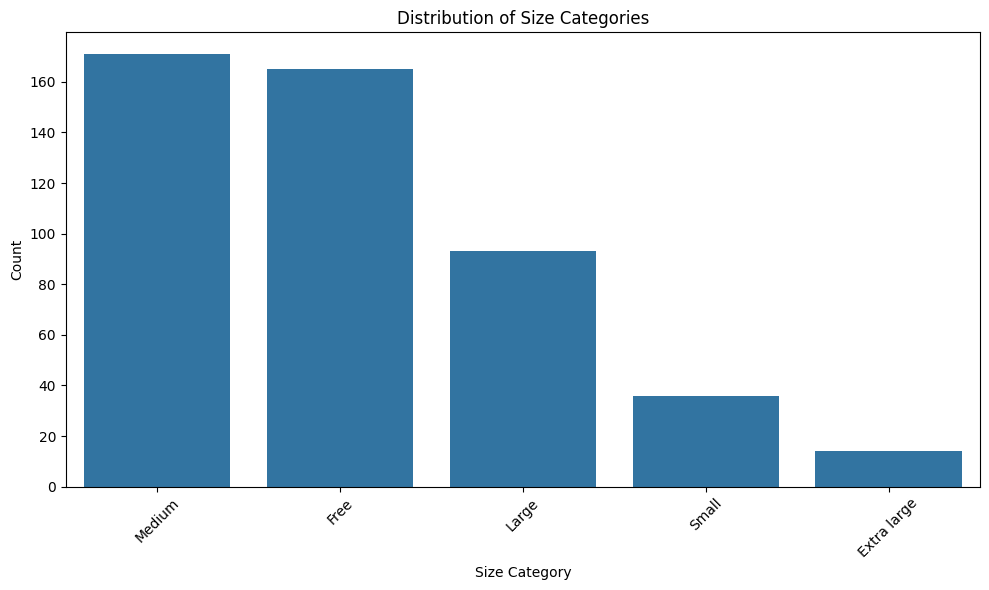

In [5]:
# Print the value counts of each category in "Size" column.
# Display the count of each size category
size_value_counts = inp0['Size'].value_counts()
print("Count of each size category:")
print(size_value_counts)

# Create a bar plot to visualize the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=size_value_counts.index, y=size_value_counts.values)
plt.title('Distribution of Size Categories')
plt.xlabel('Size Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Impute/Remove Missing values

Null values in inp0 (Attribute DataSet):
Dress_ID            0
Style               0
Price               2
Rating              0
Size                0
Season              2
NeckLine            3
SleeveLength        2
Material          119
FabricType        256
Decoration        224
Pattern Type      102
Recommendation      0
dtype: int64

Total null values in inp0: 710

Null values in inp1 (Dress Sales):
Dress_ID        0
29-08-2013      0
31-08-2013      0
09-02-2013      0
09-04-2013      0
09-06-2013      0
09-08-2013      0
09-10-2013      0
09-12-2013      0
14-09-2013      0
16-09-2013      0
18-09-2013      0
20-09-2013      0
22-09-2013      0
24-09-2013      0
26-09-2013    222
28-09-2013      0
30-09-2013    257
10-02-2013    259
10-04-2013    258
10-06-2013      0
10-08-2013    255
10-10-2013    255
10-12-2013      0
dtype: int64

Total null values in inp1: 1506


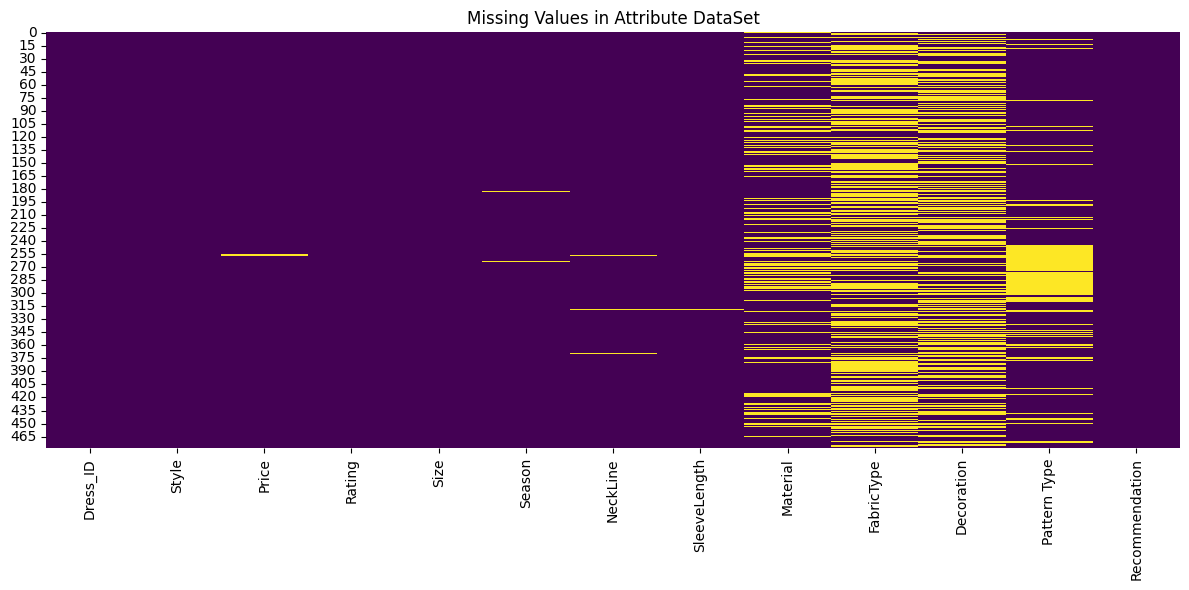

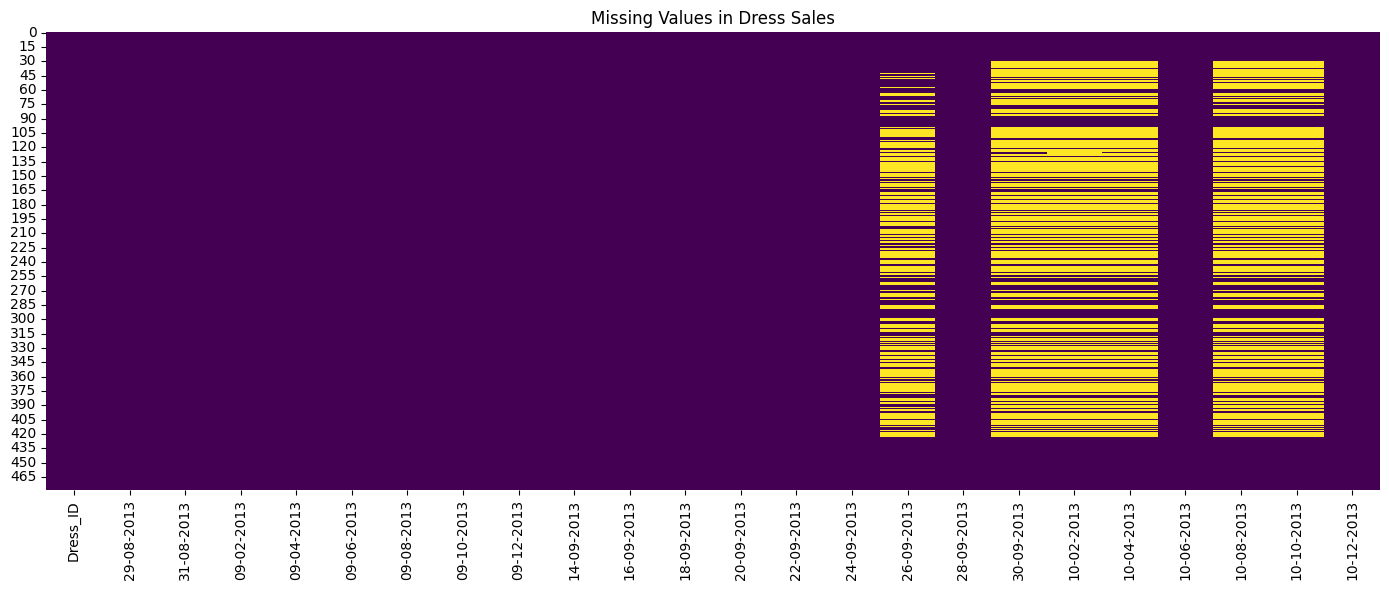

In [6]:
# Print the null count of each variables of inp0 and inp1.
# Check null values in inp0 (Attribute DataSet)
print("Null values in inp0 (Attribute DataSet):")
print(inp0.isnull().sum())
print("\nTotal null values in inp0:", inp0.isnull().sum().sum())

# Check null values in inp1 (Dress Sales)
print("\nNull values in inp1 (Dress Sales):")
print(inp1.isnull().sum())
print("\nTotal null values in inp1:", inp1.isnull().sum().sum())

# Visualize null values in inp0
plt.figure(figsize=(12, 6))
sns.heatmap(inp0.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in Attribute DataSet')
plt.tight_layout()
plt.show()

# Visualize null values in inp1
plt.figure(figsize=(14, 6))
sns.heatmap(inp1.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values in Dress Sales')
plt.tight_layout()
plt.show()

You are given another dataset named “Dress Sales”. Now if you observe the datatypes of the columns using ‘inp1.info()’ command, you can identify that there are certain columns defined as object data type though they primarily consist of numeric data.

Now if you try and convert these object data type columns into numeric data type(float), you will come across an error message. Try to correct this error.







In [7]:
# Print the data types information of inp1 i.e. "Dress Sales" data.
print("Data types in inp1 (Dress Sales):")
inp1.info()

# Check which columns are object type but might actually contain numeric data
object_cols = inp1.select_dtypes(include=['object']).columns
print("\nSample values from object columns:")
for col in object_cols:
    if col != 'Dress_ID':  # Skip the ID column
        print(f"\n{col} sample values:")
        print(inp1[col].sample(5).values)  # Print some sample values


Data types in inp1 (Dress Sales):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Dress_ID    479 non-null    float64
 1   29-08-2013  479 non-null    int64  
 2   31-08-2013  479 non-null    int64  
 3   09-02-2013  479 non-null    int64  
 4   09-04-2013  479 non-null    int64  
 5   09-06-2013  479 non-null    int64  
 6   09-08-2013  479 non-null    int64  
 7   09-10-2013  479 non-null    int64  
 8   09-12-2013  479 non-null    object 
 9   14-09-2013  479 non-null    object 
 10  16-09-2013  479 non-null    object 
 11  18-09-2013  479 non-null    object 
 12  20-09-2013  479 non-null    object 
 13  22-09-2013  479 non-null    object 
 14  24-09-2013  479 non-null    int64  
 15  26-09-2013  257 non-null    float64
 16  28-09-2013  479 non-null    int64  
 17  30-09-2013  222 non-null    float64
 18  10-02-2013  220 non-null    float64


In [8]:
# Try to convert the object type into float type of data. YOU GET ERROR MESSAGE.
# This will cause an error because some values in the columns might not be numeric
print("Attempting direct conversion (will raise errors):")
try:
    # Try to convert the first date column to demonstrate the error
    col = inp1.columns[1]  # First date column
    print(f"Converting {col} to float...")
    # This will fail
    inp1[col] = inp1[col].astype(float)
except Exception as e:
    print(f"Error: {e}")
    
# Let's examine the problematic values
print("\nExamining problematic values:")
for col in inp1.columns:
    if col != 'Dress_ID':  # Skip the ID column
        # Check which values are causing problems
        non_convertible = []
        for val in inp1[col].unique():
            try:
                float(val)
            except (ValueError, TypeError):
                if pd.isna(val) == False:  # Ignore NaN values
                    non_convertible.append(val)
        
        if non_convertible:
            print(f"\nColumn {col} has non-convertible values: {non_convertible}")


Attempting direct conversion (will raise errors):
Converting 29-08-2013 to float...

Examining problematic values:

Column 09-12-2013 has non-convertible values: ['Removed']

Column 14-09-2013 has non-convertible values: ['removed']

Column 16-09-2013 has non-convertible values: ['removed']

Column 18-09-2013 has non-convertible values: ['removed']

Column 20-09-2013 has non-convertible values: ['removed']

Column 22-09-2013 has non-convertible values: ['Orders']


In [9]:
# Do the required changes in the "Dress Sales" data set to get null values on string values.
# Function to replace string values with NaN
def convert_to_numeric_or_nan(val):
    if pd.isna(val):
        return np.nan
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan

# Apply the function to all columns except Dress_ID
for col in inp1.columns:
    if col != 'Dress_ID':
        inp1[col] = inp1[col].apply(convert_to_numeric_or_nan)

# Check the results of conversion
print("After replacing non-numeric values with NaN:")
print(inp1.head())

# Count the number of NaN values after conversion
print("\nNumber of NaN values after conversion:")
print(inp1.isnull().sum())


After replacing non-numeric values with NaN:
       Dress_ID  29-08-2013  31-08-2013  09-02-2013  09-04-2013  09-06-2013  \
0  1.006033e+09      2114.0      2274.0      2491.0      2660.0      2727.0   
1  1.212192e+09       151.0       275.0       570.0       750.0       813.0   
2  1.190381e+09         6.0         7.0         7.0         7.0         8.0   
3  9.660060e+08      1005.0      1128.0      1326.0      1455.0      1507.0   
4  8.763395e+08       996.0      1175.0      1304.0      1396.0      1432.0   

   09-08-2013  09-10-2013  09-12-2013  14-09-2013  ...  24-09-2013  \
0      2887.0      2930.0      3119.0      3204.0  ...      3554.0   
1      1066.0      1164.0      1558.0      1756.0  ...      2710.0   
2         8.0         9.0        10.0        10.0  ...        11.0   
3      1621.0      1637.0      1723.0      1746.0  ...      1878.0   
4      1559.0      1570.0      1638.0      1655.0  ...      2032.0   

   26-09-2013  28-09-2013  30-09-2013  10-02-2013  10-04-20

In [10]:
# Convert the object type columns in "Dress Sales" into float type of data type.
# Now we can safely convert all columns (except Dress_ID) to float64
for col in inp1.columns:
    if col != 'Dress_ID':
        inp1[col] = inp1[col].astype('float64')

# Verify that the conversion worked correctly
print("Data types after conversion:")
inp1.info()

# Check the first few rows to ensure data integrity
print("\nFirst few rows after type conversion:")
print(inp1.head())

# Calculate basic statistics to make sure the converted data is valid
print("\nBasic statistics of numeric columns:")
print(inp1.describe())


Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Dress_ID    479 non-null    float64
 1   29-08-2013  479 non-null    float64
 2   31-08-2013  479 non-null    float64
 3   09-02-2013  479 non-null    float64
 4   09-04-2013  479 non-null    float64
 5   09-06-2013  479 non-null    float64
 6   09-08-2013  479 non-null    float64
 7   09-10-2013  479 non-null    float64
 8   09-12-2013  478 non-null    float64
 9   14-09-2013  478 non-null    float64
 10  16-09-2013  478 non-null    float64
 11  18-09-2013  478 non-null    float64
 12  20-09-2013  478 non-null    float64
 13  22-09-2013  478 non-null    float64
 14  24-09-2013  479 non-null    float64
 15  26-09-2013  257 non-null    float64
 16  28-09-2013  479 non-null    float64
 17  30-09-2013  222 non-null    float64
 18  10-02-2013  220 non-null    float64
 19  

When you see the null counts in “Dress Sales” dataset after performing all the operations that have been mentioned in jupyter notebook, you will find that there are some columns in “Dress Sales” data where there are more than 40% of missing values. Based on your understanding of dealing with missing values do the following steps.

Null percentage of each column in inp1 (Dress Sales):
Dress_ID       0.000000
29-08-2013     0.000000
31-08-2013     0.000000
09-02-2013     0.000000
09-04-2013     0.000000
09-06-2013     0.000000
09-08-2013     0.000000
09-10-2013     0.000000
09-12-2013     0.208768
14-09-2013     0.208768
16-09-2013     0.208768
18-09-2013     0.208768
20-09-2013     0.208768
22-09-2013     0.208768
24-09-2013     0.000000
26-09-2013    46.346555
28-09-2013     0.000000
30-09-2013    53.653445
10-02-2013    54.070981
10-04-2013    53.862213
10-06-2013     0.000000
10-08-2013    53.235908
10-10-2013    53.235908
10-12-2013     0.000000
dtype: float64


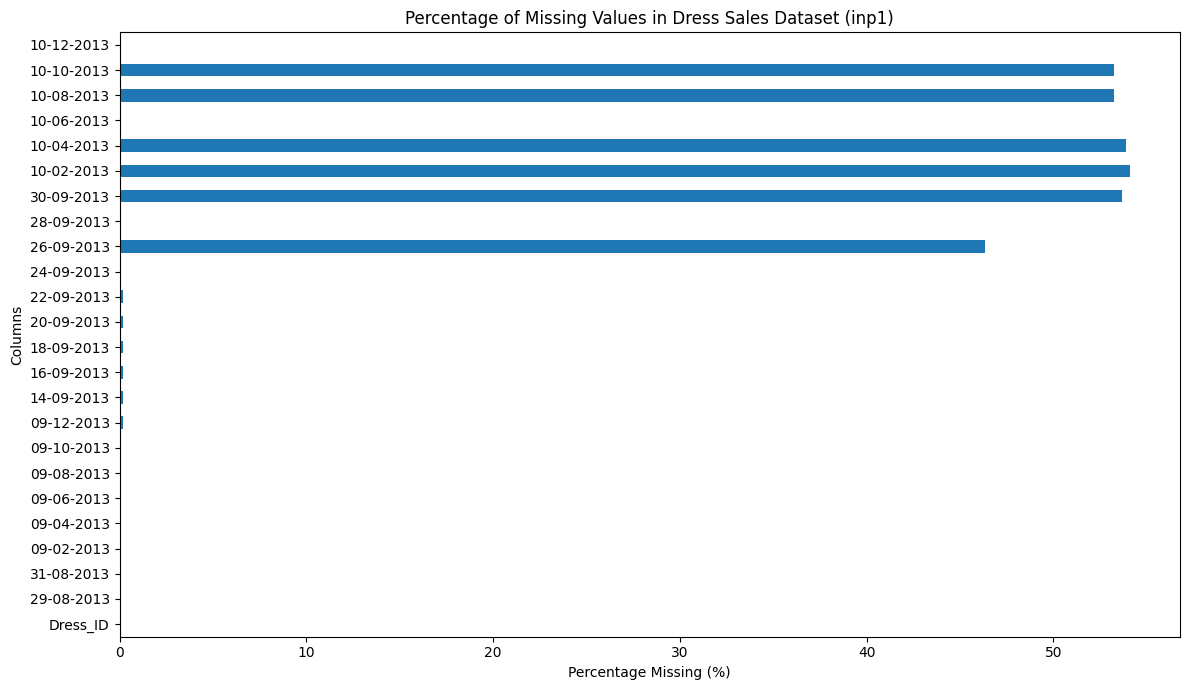

In [11]:
# Print the null percetange of each column of inp1.
# Calculate null percentage for each column in inp1
null_percentage_inp1 = (inp1.isnull().sum() / len(inp1)) * 100
print("Null percentage of each column in inp1 (Dress Sales):")
print(null_percentage_inp1)

# Visualize null percentages
plt.figure(figsize=(12, 7))
null_percentage_inp1.plot(kind='barh')
plt.title('Percentage of Missing Values in Dress Sales Dataset (inp1)')
plt.xlabel('Percentage Missing (%)')
plt.ylabel('Columns')
plt.tight_layout()
plt.show()


In [12]:
# Drop the columns in "Dress Sales" which have more than 40% of missing values.
# Calculate null percentage again (in case it was not run in the previous cell or for clarity)
null_percentage_inp1 = (inp1.isnull().sum() / len(inp1)) * 100

# Identify columns to drop (more than 40% missing values)
cols_to_drop = null_percentage_inp1[null_percentage_inp1 > 40].index
print(f"Columns to drop (more than 40% missing values): {list(cols_to_drop)}")

# Drop the identified columns from inp1
inp1.drop(columns=cols_to_drop, inplace=True)

# Print the shape of the dataframe after dropping columns
print(f"\nShape of inp1 after dropping columns: {inp1.shape}")

# Verify by printing null percentages again for the remaining columns
remaining_null_percentage_inp1 = (inp1.isnull().sum() / len(inp1)) * 100
print("\nNull percentage of remaining columns in inp1:")
print(remaining_null_percentage_inp1)

Columns to drop (more than 40% missing values): ['26-09-2013', '30-09-2013', '10-02-2013', '10-04-2013', '10-08-2013', '10-10-2013']

Shape of inp1 after dropping columns: (479, 18)

Null percentage of remaining columns in inp1:
Dress_ID      0.000000
29-08-2013    0.000000
31-08-2013    0.000000
09-02-2013    0.000000
09-04-2013    0.000000
09-06-2013    0.000000
09-08-2013    0.000000
09-10-2013    0.000000
09-12-2013    0.208768
14-09-2013    0.208768
16-09-2013    0.208768
18-09-2013    0.208768
20-09-2013    0.208768
22-09-2013    0.208768
24-09-2013    0.000000
28-09-2013    0.000000
10-06-2013    0.000000
10-12-2013    0.000000
dtype: float64


You should categorise the dates into seasons in “Dress Sales” data to simplify the analysis according to the following criteria:
- June, July and August: Summer.
- September, October and November: Autumn.
- December, January and February: WInter.
- March, April and May: Spring.




In [13]:
# Create the four seasons columns in inp1, according to the above criteria.

# Function to get season from date
def get_season(date_str):
    # Parse date in DD-MM-YYYY format
    parts = date_str.split('-')
    month = int(parts[1])  # Get the month from DD-MM-YYYY format
    
    if month in [6, 7, 8]:  # Summer: June, July, August
        return 'Summer'
    elif month in [9, 10, 11]:  # Autumn: September, October, November
        return 'Autumn'
    elif month in [12, 1, 2]:  # Winter: December, January, February
        return 'Winter'
    else:  # Spring: March, April, May
        return 'Spring'

# Initialize seasonal columns with zeros
inp1['Summer'] = 0
inp1['Autumn'] = 0
inp1['Winter'] = 0
inp1['Spring'] = 0

# Iterate through the date columns (excluding Dress_ID)
for col in inp1.columns:
    if col != 'Dress_ID' and col not in ['Summer', 'Autumn', 'Winter', 'Spring']:
        try:
            # Get the season for the date column
            season = get_season(col)
            # Add the sales to the corresponding season column
            inp1[season] += inp1[col]
        except:
            print(f"Could not process column: {col}")

# Display sample results
print("Seasonal sales summary:")
print(inp1[['Dress_ID', 'Summer', 'Autumn', 'Winter', 'Spring']].head())

# Display basic statistics for each season
print("\nSeasonal statistics:")
print(inp1[['Summer', 'Autumn', 'Winter', 'Spring']].describe())


Seasonal sales summary:
       Dress_ID   Summer   Autumn  Winter  Spring
0  1.006033e+09  13899.0  26857.0  9658.0  2660.0
1  1.212192e+09   6216.0  17311.0  6405.0   750.0
2  1.190381e+09     40.0     82.0    28.0     7.0
3  9.660060e+08   7213.0  14411.0  5012.0  1455.0
4  8.763395e+08   7706.0  14676.0  5678.0  1396.0

Seasonal statistics:
             Summer        Autumn        Winter       Spring
count    479.000000    477.000000    478.000000   479.000000
mean    1444.482255   2837.616352    990.878661   299.791232
std     2976.993959   5010.790796   1851.691244   601.716515
min        2.000000      1.000000      0.000000     1.000000
25%      156.500000    406.000000    122.000000    28.500000
50%      518.000000   1329.000000    400.000000   110.000000
75%     1475.500000   3122.000000   1097.000000   308.500000
max    35577.000000  55532.000000  20388.000000  7374.000000


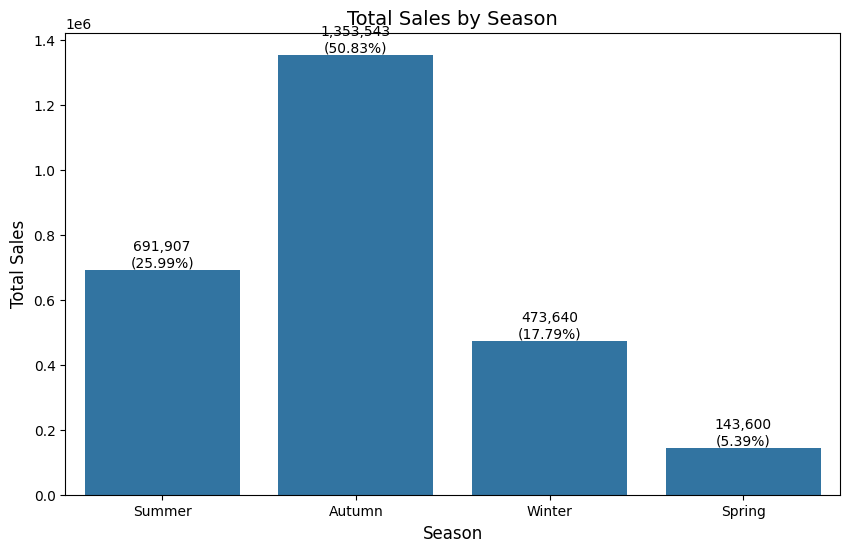


Seasonal Sales Summary:
Summer: 691,907 sales (25.99% of total)
Autumn: 1,353,543 sales (50.83% of total)
Winter: 473,640 sales (17.79% of total)
Spring: 143,600 sales (5.39% of total)

Season with highest sales: Autumn (1,353,543)
Season with lowest sales: Spring (143,600)
Difference between highest and lowest: 1,209,943


In [14]:
# Calculate the sum of sales in each seasons in inp1 i.e. "Dress Sales".

# Calculate total sales for each season
seasonal_totals = inp1[['Summer', 'Autumn', 'Winter', 'Spring']].sum()
total_sales = seasonal_totals.sum()

# Calculate percentages
percentages = (seasonal_totals / total_sales * 100).round(2)

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=seasonal_totals.index, y=seasonal_totals.values)

# Customize the plot
plt.title('Total Sales by Season', fontsize=14)
plt.xlabel('Season', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

# Add value labels on top of each bar
for i, (sales, pct) in enumerate(zip(seasonal_totals, percentages)):
    plt.text(i, sales, f'{sales:,.0f}\n({pct}%)', 
             ha='center', va='bottom')

plt.show()

# Print summary
print("\nSeasonal Sales Summary:")
for season, sales, pct in zip(seasonal_totals.index, seasonal_totals, percentages):
    print(f"{season}: {sales:,.0f} sales ({pct}% of total)")

# Find the season with the highest and lowest sales
max_season = seasonal_totals.idxmax()
min_season = seasonal_totals.idxmin()

print(f"\nSeason with highest sales: {max_season} ({seasonal_totals[max_season]:,.0f})")
print(f"Season with lowest sales: {min_season} ({seasonal_totals[min_season]:,.0f})")
print(f"Difference between highest and lowest: {seasonal_totals[max_season] - seasonal_totals[min_season]:,.0f}")


Print the null count of inp0 to get the idea about the missing values in data set.

In [15]:
# Print the null count of each columns in inp0 dataframe i.e. combined data frame of inp0 and inp1 without date columns.


You can see that there are two types of variables one with a large number of missing values and another is very less number of missing values. These two columns can be categorized as:

Type-1: Missing values are very less (around 2 or 3 missing values): Price, Season, NeckLine, SleeveLength, Winter and Autumn. 

Type-2: Missing values are large in numbers (more than 15%): Material, FabricType, Decoration and Pattern Type.



In [16]:
# Deal with the missing values of Type-1 columns: Price, Season, NeckLine, SleeveLength, Winter and Autumn.


In [17]:
# Deal with the missing values for Type-2 columns: Material, FabricType, Decoration and Pattern Type.


### Standardise value 

In the given dataset, there are certain discrepancies with the categorical names such as irregular spellings. Choose the correct option of columns with irregular categories and update them.
 
- Season, NeckLine
- Price, Material
- fabricType, Decoration
- Season, SleeveLength


In [18]:
#correcting the spellings.


In [19]:
#correcting the Spellings.


## Univariate Analysis 

### Categorical Unordered Univariate Analysis
 

There is a column named ‘Style’ in ‘Attribute Dataset’ which consists of the different style categories of the women apparels. Certain categories whose total sale is less than 50000 across all the seasons is considered under one single category as ‘Others’.


Which of the following categories in ‘Style’ column can be grouped into ‘Others’ category? and perform the grouping operation in the notebook for further analysis.
- Flare, fashion
- Novelty, bohemian
- OL, fashion, work
- Novelty, fashion, Flare


In [20]:
# Group "Style" categories into "Others" which have less than 50000 sales across all the seasons.


What is the percentage of “cute” and “Others” category in “Style” column in “Attribute DataSet” respectively?
- 46%, 5%
- 9%, 2.1%
- 2.1%, 5%
- 13.8%, 9%


In [21]:
# Calculate the percentage of each categories in the "Style" variable.


Similarly Club Neckline, SLeeve length categories into "Others" which have less than 50000 sales across all the seasons.

In [22]:
# Group "Neckline" categories into "Others" which have less than 50000 sales across all the seasons.


In [23]:
# Group "Sleeve length" categories into "Others" which have less than 50000 sales across all the seasons.


Club material, fabrictype, patterntype and decoration categories into "Others" which have less than 25000 sales across all the seasons

In [24]:
# Group "material" categories into "Others" which have less than 25000 sales across all the seasons.


In [25]:
# Group "fabric type" categories into "Others" which have less than 25000 sales across all the seasons.


In [26]:
# Group "patern type" categories into "Others" which have less than 25000 sales across all the seasons.


In [27]:
# Group "decoration" categories into "Others" which have less than 25000 sales across all the seasons.


### Caregorical Ordered Univariate Analysis

Which of the following is an unordered variable in “Attribute DataSet”.
- Style
- Price
- Season
- Size


### Numerical variable Univariate analysis:

What is the approximate difference between the maximum value and 75th percentile in “Autumn” column.
- Approx 54000
- Approx 55000
- Approx 52000
- Approx 50000



In [28]:
# Describe the numerical variale: "Autumn".


In [29]:
# plot the boxplot of "Autumn" column.


Which of the following season has the highest difference between the maximum value and 99th quantile of sales?
- Winter
- Summer
- Spring
- Autumn


In [30]:
# Find the maximum and 99th percentile of Winter season.


In [31]:
# Find the maximum and 99th percentile of Summer season.


In [32]:
# Find the maximum and 99th percentile of Spring season.


In [33]:
# Find the maximum and 99th percentile of Autumn season.


## Bivariate Analysis 

### Numerical- Categorical analysis

Which of the following “Price” category has the lowest average value of rating?
- very-high
- Medium
- Low
- High


In [34]:
# Find the Mean of Ratings for each Price category.


What is the median of the rating of “vintage” category in Style column?
- 4.6
- 4.7
- 4.55
- 0.00


In [35]:
# Find the median of Ratings for each Style category.


Which of the following season has the highest average value of sale for “Recommendation” value equals to 1.
- Summer
- Spring
- Autumn
- Winter


In [36]:
# Summer sale vs Recommendation.


In [37]:
# Spring sale vs Recommendation.


In [38]:
# Autumn sale vs Recommendation.


In [39]:
# Winter sale vs Recommendation.


### Categorical categorical bivariate analysis


Which of the following size categories has the highest positive recommendations?
- Medium and extra large
- Extra large and small
- Free and small
- Free and medium


In [40]:
# Size vs Recommendation.


### Multivariate analysis 

Which of the following pair of “Style” and “Price” category has the highest average of positive recommendations?
- Price: medium and style: vintage
- Price: medium and style: cute
- Price: very high and style: party
- Price: low and style: sexy


In [41]:
# plot the heat map of Style, price and Recommendation.


Which of the following material type has no recommendation in summer and winter seasons?
- Mix and Milksilk
- Nylon and Rayon
- Microfiber and Silk
- Milksilk and Microfiber


In [42]:
# plot the heat map of Season, material and Recommendation.
